In [1]:
from pathlib import Path
import importlib
import json
import random
import sys
import time
import uuid

import imageio.v2 as imageio
import numpy as np
import pybullet as p


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / 'calvin_experiments' / 'calvin_rollout_utils.py').exists():
            return path
    raise FileNotFoundError(f'Could not find guided-diffusion repo root from {start}')


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'robomimic'))
sys.path.insert(0, str(REPO_ROOT / 'calvin' / 'calvin_env'))

import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import calvin_experiments.calvin_rollout_utils as CalvinRolloutUtils

CalvinRolloutUtils = importlib.reload(CalvinRolloutUtils)
from calvin_experiments.calvin_rollout_utils import articulated_binaries_from_start_state, check_state_difference, classify_behavior

def seed_everything(seed):
    if seed is None:
        return
    random.seed(seed)
    np.random.seed(seed)
    torch_module = sys.modules.get('torch')
    if torch_module is not None:
        torch_module.manual_seed(seed)
        if torch_module.cuda.is_available():
            torch_module.cuda.manual_seed_all(seed)
        torch_module.backends.cudnn.benchmark = False
        torch_module.backends.cudnn.deterministic = True



CONFIG_DIR = REPO_ROOT / 'calvin_experiments' / 'configs'
VISUALIZATION_CONFIG_PATH = CONFIG_DIR / 'visualization_freiburg_style.json'

CHECKPOINT_PATH = '/home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth' 

OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'calvin' / 'base_tests'
VIDEO_FPS = 30

SCENE_INDEX = {
    'sliding_door': 0,
    'drawer': 1,
    'button': 2,
    'switch': 3,
    'lightbulb': 4,
    'green_light': 5,
}
BLOCK_POSE_SLICES = {
    'block_red': (6, 9, 9, 12),
    'block_blue': (12, 15, 15, 18),
    'block_pink': (18, 21, 21, 24),
}


def get_calvin_unwrapped_env(env):
    """Return the underlying CALVIN gym env through robomimic wrappers."""
    current = env
    while hasattr(current, 'env'):
        child = current.env
        if hasattr(child, 'unwrapped'):
            return child.unwrapped
        current = child
    raise AttributeError('Could not find underlying CALVIN env')


def is_env_connected(env):
    try:
        calvin_env = get_calvin_unwrapped_env(env)
        info = calvin_env.p.getConnectionInfo(physicsClientId=calvin_env.cid)
        return bool(info.get('isConnected', False))
    except Exception:
        return False


def reset_env_to_scene_robot(env, scene, robot):
    """Reset CALVIN to an explicit scene / robot state while keeping Gym wrappers in sync."""
    state = {'scene': np.asarray(scene, dtype=np.float32).copy(), 'robot': np.asarray(robot, dtype=np.float32).copy()}
    robomimic_env = env
    frame_stack_env = env if hasattr(env, '_get_initial_obs_history') else None
    if frame_stack_env is not None:
        robomimic_env = frame_stack_env.env
    gym_env = getattr(robomimic_env, 'env', None)
    if gym_env is not None and hasattr(gym_env, 'reset') and hasattr(robomimic_env, 'get_observation'):
        raw_obs = gym_env.reset(scene_obs=state['scene'], robot_obs=state['robot'])
        if isinstance(raw_obs, tuple):
            raw_obs = raw_obs[0]
        robomimic_env._current_obs = raw_obs
        robomimic_env._current_reward = None
        robomimic_env._current_done = None
        obs = robomimic_env.get_observation(raw_obs)
        if frame_stack_env is not None:
            frame_stack_env.timestep = 0
            frame_stack_env.update_obs(obs, reset=True)
            frame_stack_env.obs_history = frame_stack_env._get_initial_obs_history(init_obs=obs)
            return frame_stack_env._get_stacked_obs_from_history()
        return obs
    return env.reset_to(state)


def resolve_checkpoint_path(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.is_absolute():
        checkpoint_path = REPO_ROOT / checkpoint_path
    if checkpoint_path.is_dir():
        candidates = sorted(checkpoint_path.glob('*.pth'), key=lambda path: path.stat().st_mtime)
        if not candidates:
            raise FileNotFoundError(f'No .pth checkpoints found in {checkpoint_path}')
        checkpoint_path = candidates[-1]
        print(f'Using newest checkpoint in models folder: {checkpoint_path}')
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Policy checkpoint not found: {checkpoint_path}')
    return checkpoint_path


def render_visual_camera(env, video_cfg):
    """Notebook-only camera. Does not affect policy observations or env metadata."""
    if video_cfg.get('perspective') == 'third_person':
        return env.render(
            mode='rgb_array',
            height=int(video_cfg['height']),
            width=int(video_cfg['width']),
        )

    calvin_env = get_calvin_unwrapped_env(env)
    width = int(video_cfg['width'])
    height = int(video_cfg['height'])
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=video_cfg['look_from'],
        cameraTargetPosition=video_cfg['look_at'],
        cameraUpVector=video_cfg['up_vector'],
    )
    projection_matrix = p.computeProjectionMatrixFOV(
        fov=float(video_cfg['fov']),
        aspect=width / height,
        nearVal=float(video_cfg['nearval']),
        farVal=float(video_cfg['farval']),
    )
    image = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix,
        physicsClientId=calvin_env.cid,
    )
    return np.reshape(image[2], (height, width, 4))[:, :, :3].astype(np.uint8)


def apply_block_scene_overrides(scene, blocks_cfg):
    """Set block poses through scene_obs before reset_to, preserving env structure."""
    applied = []
    for name, pose_cfg in blocks_cfg.get('poses', {}).items():
        if name not in BLOCK_POSE_SLICES:
            print(f'Unknown block name in blocks.poses: {name}')
            continue
        pos_start, pos_end, rot_start, rot_end = BLOCK_POSE_SLICES[name]
        if isinstance(pose_cfg, dict):
            position = pose_cfg.get('position')
            rotation = pose_cfg.get('rotation', [0.0, 0.0, 0.0])
        else:
            position = pose_cfg
            rotation = [0.0, 0.0, 0.0]
        scene[pos_start:pos_end] = np.asarray(position, dtype=np.float32)
        scene[rot_start:rot_end] = np.asarray(rotation, dtype=np.float32)
        applied.append(name)
    return applied



pybullet build time: Jan 29 2025 23:16:28
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
from matplotlib.patches import Circle, Rectangle


def _pose_from_joint_object(obj):
    link_state = obj.p.getLinkState(obj.uid, obj.joint_index, physicsClientId=obj.cid)
    position = np.asarray(link_state[4], dtype=np.float32)
    orientation = np.asarray(link_state[5], dtype=np.float32)
    return position, orientation


def _pose_from_link_object(obj, link_index):
    link_state = obj.p.getLinkState(obj.uid, link_index, physicsClientId=obj.cid)
    position = np.asarray(link_state[4], dtype=np.float32)
    orientation = np.asarray(link_state[5], dtype=np.float32)
    return position, orientation


def _pose_from_body_object(obj):
    position, orientation = obj.p.getBasePositionAndOrientation(obj.uid, physicsClientId=obj.cid)
    return np.asarray(position, dtype=np.float32), np.asarray(orientation, dtype=np.float32)


def _aabb_from_object(obj, link_index=None):
    if link_index is None:
        lower, upper = obj.p.getAABB(obj.uid, physicsClientId=obj.cid)
    else:
        lower, upper = obj.p.getAABB(obj.uid, link_index, physicsClientId=obj.cid)
    return np.asarray(lower, dtype=np.float32), np.asarray(upper, dtype=np.float32)


def capture_scene_snapshot(env):
    calvin_env = get_calvin_unwrapped_env(env)
    scene = calvin_env.scene
    snapshot = {
        'fixed_objects': [],
        'controls': [],
        'blocks': [],
    }

    for obj in scene.fixed_objects:
        position, orientation = _pose_from_body_object(obj)
        lower, upper = _aabb_from_object(obj)
        snapshot['fixed_objects'].append({
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
        })

    for obj in scene.buttons:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        snapshot['controls'].append({
            'kind': 'button',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.doors:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        kind = 'drawer' if 'drawer' in obj.name else 'slider' if 'slide' in obj.name else 'door'
        snapshot['controls'].append({
            'kind': kind,
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.switches:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        snapshot['controls'].append({
            'kind': 'switch',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.lights:
        position, orientation = _pose_from_link_object(obj, obj.link_id)
        lower, upper = _aabb_from_object(obj, obj.link_id)
        snapshot['controls'].append({
            'kind': 'light',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.movable_objects:
        position, orientation = _pose_from_body_object(obj)
        lower, upper = _aabb_from_object(obj)
        snapshot['blocks'].append({
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
        })

    return snapshot


def save_scene_snapshot(snapshot, path):
    with open(path, 'w') as f:
        json.dump(snapshot, f, indent=2)


def _rect_from_aabb(ax, lower, upper, **kwargs):
    width = float(upper[0] - lower[0])
    height = float(upper[1] - lower[1])
    patch = Rectangle((float(lower[0]), float(lower[1])), width, height, **kwargs)
    ax.add_patch(patch)
    return patch


def _circle_from_aabb(ax, lower, upper, **kwargs):
    center = ((float(lower[0]) + float(upper[0])) / 2, (float(lower[1]) + float(upper[1])) / 2)
    radius = 0.5 * min(float(upper[0] - lower[0]), float(upper[1] - lower[1]))
    patch = Circle(center, radius=radius, **kwargs)
    ax.add_patch(patch)
    return patch


def _scene_limits_from_snapshot(snapshot, eef_xy, padding=0.05):
    boxes = []
    for group in ('controls',):
        for item in snapshot.get(group, []):
            if 'aabb' in item:
                lower = np.asarray(item['aabb'][0], dtype=np.float32)
                upper = np.asarray(item['aabb'][1], dtype=np.float32)
                boxes.append((lower, upper))
    if not boxes:
        return (-0.4, 0.4), (-0.4, 0.25)

    lower_xy = np.min([box[0][:2] for box in boxes], axis=0)
    upper_xy = np.max([box[1][:2] for box in boxes], axis=0)
    lower_xy = np.minimum(lower_xy, np.min(eef_xy[:, :2], axis=0))
    upper_xy = np.maximum(upper_xy, np.max(eef_xy[:, :2], axis=0))
    return (float(lower_xy[0] - padding), float(upper_xy[0] + padding)), (float(lower_xy[1] - padding), float(upper_xy[1] + padding))


def draw_scene_snapshot(ax, snapshot, eef_xy=None):
    kind_styles = {
        'button': {'facecolor': '#111111', 'edgecolor': '#000000', 'alpha': 0.95},
        'slider': {'facecolor': '#4c566a', 'edgecolor': '#1f2937', 'alpha': 0.92},
        'drawer': {'facecolor': '#7a5c4d', 'edgecolor': '#2f241f', 'alpha': 0.9},
        'switch': {'facecolor': '#6b7280', 'edgecolor': 'black', 'alpha': 0.9},
        'light': {'facecolor': '#9ca3af', 'edgecolor': 'black', 'alpha': 0.75},
    }

    for control in snapshot.get('controls', []):
        lower = np.asarray(control['aabb'][0], dtype=np.float32)
        upper = np.asarray(control['aabb'][1], dtype=np.float32)
        kind = control['kind']
        style = kind_styles.get(kind, {'facecolor': '#adb5bd', 'edgecolor': 'black', 'alpha': 0.8})
        if kind == 'button':
            _circle_from_aabb(
                ax,
                lower,
                upper,
                facecolor=style['facecolor'],
                edgecolor=style['edgecolor'],
                linewidth=1.0,
                alpha=style['alpha'],
            )
        else:
            _rect_from_aabb(
                ax,
                lower,
                upper,
                facecolor=style['facecolor'],
                edgecolor=style['edgecolor'],
                linewidth=1.0,
                alpha=style['alpha'],
            )
        label_x = float((lower[0] + upper[0]) / 2)
        label_y = float(upper[1] + 0.01)
        ax.text(label_x, label_y, control['name'].replace('base__', ''), ha='center', va='bottom', fontsize=7, color='black')

    if eef_xy is not None and len(eef_xy) > 0:
        ax.plot(eef_xy[:, 0], eef_xy[:, 1], color='#ff3b30', linewidth=2.5, label='EEF XY path')
        ax.scatter(eef_xy[0, 0], eef_xy[0, 1], c='#4b5563', s=55, edgecolors='white', linewidths=1.0, label='start')
        ax.scatter(eef_xy[-1, 0], eef_xy[-1, 1], c='#111827', s=55, edgecolors='white', linewidths=1.0, label='end')

    ax.set_aspect('equal')
    ax.grid(color='white', alpha=0.2, linewidth=0.8)


In [3]:
import robomimic.utils.torch_utils as TorchUtils
import torch

checkpoint_path = CHECKPOINT_PATH

if not checkpoint_path:
    print('Set CHECKPOINT_PATH in the setup cell before loading the policy.')
else:
    checkpoint_path = resolve_checkpoint_path(checkpoint_path)

    device = TorchUtils.get_torch_device(try_to_use_cuda=True)
    policy, ckpt_dict = FileUtils.policy_from_checkpoint(
        ckpt_path=str(checkpoint_path),
        device=device,
        verbose=True,
    )

    env, _ = FileUtils.env_from_checkpoint(
        ckpt_dict=ckpt_dict,
        render=False,
        render_offscreen=True,
        verbose=True,
    )
    if not is_env_connected(env):
        raise RuntimeError('Loaded env is disconnected immediately after env_from_checkpoint.')
    base_env_state = {
        key: np.asarray(value, dtype=np.float32).copy()
        for key, value in env.get_state().items()
    }
    loaded_checkpoint_path = checkpoint_path
    print(f'Loaded policy and env once from: {loaded_checkpoint_path}')


============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "calvin_D_base_dp",
        "validate": true,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "CALVIN"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 20,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 500,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": false,
        "video_skip": 1,
        "rollout": {
            "enabled": true,
            "n": 10,
            "horizon": 150,
            "rate": 10,

/home/moritz/src/guided-diffusion/calvin/calvin_env/calvin_env/envs/play_table_env.py:324: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../../conf", config_name="config_data_collection")
EGL device choice: -1 of 3.


Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
============= Loaded Environment =============
FrameStackWrapper(
    num_frames=2
    env=PlayTableSimEnv
    {
        "bullet_time_step": 240.0,
        "cameras": {
            "gripper": {
                "_target_": "calvin_env.camera.gripper_camera.GripperCamera",
                "aspect": 1,
                "farval": 2,
                "fov": 75,
                "height": 84,
                "name": "gripper",
                "nearval": 0.01,
                "width": 84
            },
 

In [13]:
SCENE_CONFIG_PATH = CONFIG_DIR / 'blocks_hidden.json'
GLOBAL_SEED = 2
ROBOT_STATE_OVERRIDE = None
NUM_ROLLOUTS = 30
HORIZON = 100
STOP_ON_BEHAVIOR = True
FOR_DISPLAY_STOP = False

if 'policy' not in globals() or 'env' not in globals():
    raise RuntimeError('Run the policy loading cell before running rollouts.')
if not is_env_connected(env):
    if 'ckpt_dict' not in globals():
        raise RuntimeError('Loaded env is disconnected and ckpt_dict is unavailable. Rerun the policy loading cell.')
    print('Loaded env is disconnected; recreating env from checkpoint metadata.')
    env, _ = FileUtils.env_from_checkpoint(
        ckpt_dict=ckpt_dict,
        render=False,
        render_offscreen=True,
        verbose=True,
    )
    base_env_state = {
        key: np.asarray(value, dtype=np.float32).copy()
        for key, value in env.get_state().items()
    }

with open(SCENE_CONFIG_PATH, 'r') as f:
    scene_cfg = json.load(f)
with open(VISUALIZATION_CONFIG_PATH, 'r') as f:
    video_cfg = json.load(f)

output_root = Path(OUTPUT_ROOT)
if not output_root.is_absolute():
    output_root = REPO_ROOT / output_root

scene_name = scene_cfg['name']
run_id = time.strftime('%Y%m%d_%H%M%S') + f'_policy_{scene_name}_' + uuid.uuid4().hex[:8]
policy_rollout_out_dir = output_root / run_id
policy_rollout_out_dir.mkdir(parents=True, exist_ok=True)

fps = int(VIDEO_FPS)
horizon = int(HORIZON)
num_rollouts = int(NUM_ROLLOUTS)
stop_on_behavior = bool(STOP_ON_BEHAVIOR)
for_display_stop = bool(FOR_DISPLAY_STOP)

policy_rollout_summaries = []

seed_everything(GLOBAL_SEED)
if 'base_env_state' not in globals():
    base_env_state = {
        key: np.asarray(value, dtype=np.float32).copy()
        for key, value in env.get_state().items()
    }
default_state = base_env_state
fixed_robot = np.asarray(default_state['robot'], dtype=np.float32).copy()
if ROBOT_STATE_OVERRIDE is not None:
    robot_override = np.asarray(ROBOT_STATE_OVERRIDE, dtype=np.float32)
    if robot_override.shape != fixed_robot.shape:
        raise ValueError(f'ROBOT_STATE_OVERRIDE must have shape {fixed_robot.shape}, got {robot_override.shape}')
    fixed_robot = robot_override.copy()
fixed_scene = np.asarray(default_state['scene'], dtype=np.float32).copy()

for name, value in scene_cfg.get('env_setup', {}).items():
    if name not in SCENE_INDEX:
        raise KeyError(f'Unknown env_setup key: {name}')
    fixed_scene[SCENE_INDEX[name]] = float(value)
apply_block_scene_overrides(fixed_scene, scene_cfg.get('blocks', {}))

scene_snapshot_path = policy_rollout_out_dir / 'scene_snapshot.json'
obs = reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
save_scene_snapshot(capture_scene_snapshot(env), scene_snapshot_path)

for rollout_idx in range(num_rollouts):
    rollout_seed = None if GLOBAL_SEED is None else GLOBAL_SEED + rollout_idx
    seed_everything(rollout_seed)
    policy.start_episode()
    obs = reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    start_state = env.get_state()
    start_scene = np.asarray(start_state['scene'], dtype=np.float32).copy()
    binaries = articulated_binaries_from_start_state(start_scene)

    frames = [render_visual_camera(env, video_cfg)]
    actions = []
    rewards = []
    dones = []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state['robot'], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]

    detected_behavior = 'none'
    detected_step = -1
    termination_step = 0
    termination_reason = 'horizon'

    for step in range(horizon):
        action = policy(ob=obs)
        obs, reward, done, info = env.step(action)
        state = env.get_state()
        scene = np.asarray(state['scene'], dtype=np.float32).copy()
        robot = np.asarray(state['robot'], dtype=np.float32).copy()

        actions.append(np.asarray(action, dtype=np.float32).copy())
        rewards.append(float(reward))
        dones.append(bool(done))
        scene_states.append(scene)
        robot_states.append(robot)
        eef_xy.append(robot[:2].copy())
        frames.append(render_visual_camera(env, video_cfg))
        termination_step = step + 1

        triggered = check_state_difference(start_scene, scene, robot[:3], binaries, for_display=for_display_stop)
        if detected_step < 0 and triggered:
            detected_behavior = classify_behavior(start_scene, scene, robot[:3], binaries, for_display=for_display_stop)
            detected_step = step + 1
            if stop_on_behavior:
                termination_reason = 'behavior'
                break
        if done:
            termination_reason = 'env_done'
            break

    rollout_dir = policy_rollout_out_dir / f'rollout_{rollout_idx:03d}'
    rollout_dir.mkdir(parents=True, exist_ok=True)
    video_path = rollout_dir / f'{scene_name}_rollout_{rollout_idx:03d}_{video_cfg["perspective"]}.mp4'
    trace_path = rollout_dir / 'rollout_trace.npz'

    imageio.mimsave(video_path, frames, fps=fps)
    np.savez_compressed(
        trace_path,
        actions=np.asarray(actions, dtype=np.float32),
        rewards=np.asarray(rewards, dtype=np.float32),
        dones=np.asarray(dones, dtype=bool),
        scene_states=np.asarray(scene_states, dtype=np.float32),
        robot_states=np.asarray(robot_states, dtype=np.float32),
        eef_xy=np.asarray(eef_xy, dtype=np.float32),
        detected_behavior=np.asarray(detected_behavior),
        detected_behavior_step=np.asarray(detected_step, dtype=np.int32),
        termination_step=np.asarray(termination_step, dtype=np.int32),
        termination_reason=np.asarray(termination_reason),
        rollout_seed=np.asarray(-1 if rollout_seed is None else rollout_seed, dtype=np.int32),
        scene_config=np.asarray(scene_name),
    )

    policy_rollout_summaries.append({
        'scene_config': scene_name,
        'rollout': rollout_idx,
        'seed': rollout_seed,
        'behavior': detected_behavior,
        'step': detected_step,
        'termination_step': termination_step,
        'termination_reason': termination_reason,
        'video': video_path,
        'trace': trace_path,
        'scene_snapshot': scene_snapshot_path,
    })

summary_path = policy_rollout_out_dir / 'policy_rollout_summary.json'
with open(summary_path, 'w') as f:
    json.dump([
        {key: str(value) if isinstance(value, Path) else value for key, value in row.items()}
        for row in policy_rollout_summaries
    ], f, indent=2)

print(f'Policy rollout output: {policy_rollout_out_dir}')
print(f'Summary JSON: {summary_path}')
print('Detected behaviors:')
for row in policy_rollout_summaries:
    print(
        f"{row['scene_config']} rollout {row['rollout']:03d} seed {row['seed']} -> "
        f"{row['behavior']} @ detected step {row['step']} | "
        f"terminated step {row['termination_step']} ({row['termination_reason']}) | "
        f"video: {row['video']}"
    )

if policy_rollout_summaries:
    try:
        from IPython.display import Video, display
        display(Video(filename=str(policy_rollout_summaries[0]['video']), embed=True))
    except Exception as exc:
        print(f'Inline video display skipped: {exc}')


Policy rollout output: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/20260504_194256_policy_blocks_hidden_7bda370a
Summary JSON: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/20260504_194256_policy_blocks_hidden_7bda370a/policy_rollout_summary.json
Detected behaviors:
blocks_hidden rollout 000 seed 2 -> none @ detected step -1 | terminated step 100 (horizon) | video: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/20260504_194256_policy_blocks_hidden_7bda370a/rollout_000/blocks_hidden_rollout_000_freiburg_style.mp4
blocks_hidden rollout 001 seed 3 -> button_on @ detected step 66 | terminated step 66 (behavior) | video: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/20260504_194256_policy_blocks_hidden_7bda370a/rollout_001/blocks_hidden_rollout_001_freiburg_style.mp4
blocks_hidden rollout 002 seed 4 -> button_on @ detected step 23 | terminated step 23 (behavior) | video: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/2026

Saved scene overlay plot: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/20260504_194256_policy_blocks_hidden_7bda370a/rollout_scene_overlay_all.png


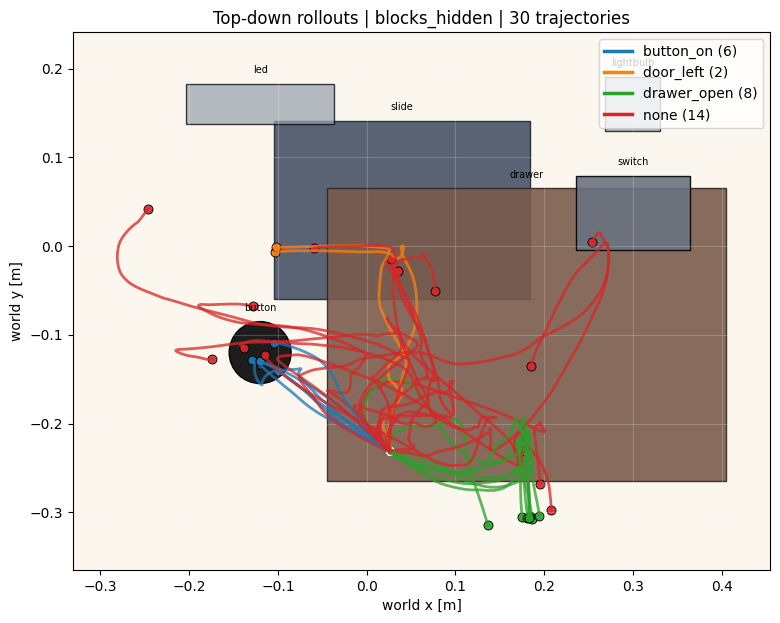

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if 'policy_rollout_summaries' not in globals() or not policy_rollout_summaries:
    print('Run the policy rollout cell below first; it writes trace .npz files for plotting.')
else:
    first_item = policy_rollout_summaries[0]
    with open(first_item['scene_snapshot'], 'r') as f:
        scene_snapshot = json.load(f)

    rollout_paths = []
    behaviors = []
    for item in policy_rollout_summaries:
        trace = np.load(item['trace'])
        rollout_paths.append(trace['eef_xy'])
        behaviors.append(item['behavior'])

    unique_behaviors = sorted(set(behaviors))
    cmap = plt.get_cmap('tab10')
    behavior_colors = {behavior: cmap(idx % cmap.N) for idx, behavior in enumerate(unique_behaviors)}
    all_eef_xy = np.concatenate(rollout_paths, axis=0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor('#fbf7ef')
    draw_scene_snapshot(ax, scene_snapshot)
    for item, eef_xy in zip(policy_rollout_summaries, rollout_paths):
        color = behavior_colors[item['behavior']]
        ax.plot(eef_xy[:, 0], eef_xy[:, 1], color=color, linewidth=2.0, alpha=0.75)
        ax.scatter(eef_xy[0, 0], eef_xy[0, 1], c=[color], s=28, edgecolors='white', linewidths=0.7, alpha=0.85)
        ax.scatter(eef_xy[-1, 0], eef_xy[-1, 1], c=[color], s=42, edgecolors='black', linewidths=0.7, alpha=0.9)

    xlim, ylim = _scene_limits_from_snapshot(scene_snapshot, all_eef_xy)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Top-down rollouts | {first_item['scene_config']} | {len(policy_rollout_summaries)} trajectories")
    ax.set_xlabel('world x [m]')
    ax.set_ylabel('world y [m]')
    legend_handles = [
        Line2D([0], [0], color=behavior_colors[behavior], lw=2.5, label=f'{behavior} ({behaviors.count(behavior)})')
        for behavior in unique_behaviors
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plot_path = Path(first_item['trace']).parents[1] / 'rollout_scene_overlay_all.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight')
    print(f'Saved scene overlay plot: {plot_path}')
    plt.show()
